In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

from process_and_save_recording import load_recording, combine_accel_gyro, add_annotations_to_combined, add_predictions_to_combined

# Load recording

In [2]:
path = "session_1777462103399"
accel, gyro, classification, annotations, info = load_recording(path)
accel.shape, gyro.shape, classification.shape, annotations.keys(), len(annotations["events"]), info

((360545, 4),
 (360545, 4),
 (7189, 6),
 dict_keys(['phoneStartTimestamp', 'phoneEndTimestamp', 'events']),
 18,
 ['start_time=1777462103997',
  'phone_timestamp=1777462103399',
  'end_time=1777469851849'])

In [3]:
accel

,timestamp,x,y,z
0,177017287198799,0.181959,-0.129287,9.722853
1,177017307230068,0.186748,-0.131681,9.761160
2,177017327272222,0.189142,-0.093374,9.816227
3,177017347310414,0.172383,-0.148441,9.825804
4,177017367352029,0.208296,-0.045490,9.725247
...,...,...,...,...
360540,184765034816440,0.304064,-6.325481,-7.503428
360541,184765054879324,0.354342,-6.809110,-7.496245
360542,184765074993940,0.035913,-6.866570,-7.486669
360543,184765095078286,0.158017,-6.880936,-7.510611


In [4]:
gyro

,timestamp,x,y,z
0,177017287201106,-0.046426,-0.006109,0.003665
1,177017307232645,-0.029322,-0.004887,-0.002443
2,177017327274529,-0.040317,-0.006109,-0.004887
3,177017347312952,-0.031765,-0.002443,-0.008552
4,177017367354375,-0.001222,-0.004887,-0.013439
...,...,...,...,...
360540,184765034818632,0.037874,0.147829,0.041539
360541,184765054881747,0.019548,0.130725,-0.002443
360542,184765074996132,0.036652,0.118508,0.024435
360543,184765095080709,0.151495,0.048869,0.040317


In [5]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1777462104036,0.014872,0,177015324722883;177015342756614;17701536279134...,177015324725345;177015342759306;17701536279380...,0.05267244|-0.3184288|9.730036|0.29443705|0.06...
1,1777462105052,0.029558,0,177016325628379;177016345636302;17701636572268...,177016325630687;177016345638879;17701636572503...,0.29927522|-0.5315128|9.78989|-0.02321288|-0.0...
2,1777462106060,0.037717,0,177017327272222;177017347310414;17701736735202...,177017327274529;177017347312952;17701736735437...,0.18914193|-0.093373865|9.816227|-0.040317107|...
3,1777462107050,0.077905,0,177018329547910;177018349617218;17701837170094...,177018329550218;177018349619795;17701837170325...,0.15083471|-0.21787235|9.706094|-0.040317107|0...
4,1777462108072,0.003745,0,177019333760522;177019351794829;17701937183232...,177019333764791;177019351797406;17701937183463...,-0.47405192|-0.50278234|9.797073|-0.04886922|-...
...,...,...,...,...,...,...
7184,1777469763270,0.350637,0,184654974690783;184654994774052;18465501486128...,184654974693244;184654994776244;18465501486370...,2.7030537|-8.990228|-3.217807|-0.41538838|0.01...
7185,1777469764491,0.302763,0,184674774326438;184674794412015;18467481449793...,184674774328630;184674794414438;18467481450016...,5.33907|-11.145009|3.3566709|-0.33108896|-0.45...
7186,1777469787305,0.022782,0,184676763719046;184676781513892;18467680161043...,184676763721469;184676781516084;18467680161289...,4.0198646|-7.788338|-0.107739076|0.16371189|0....
7187,1777469788308,0.010067,0,184677766438004;184677786552427;18467780667288...,184677766440427;184677786554619;18467780667531...,8.671799|-2.2098482|-1.5466543|0.9334021|0.076...


In [6]:
annotations

{'phoneStartTimestamp': 1777462103399,
 'phoneEndTimestamp': 1777469851565,
 'events': [{'name': 'Ab Roll Outs',
   'startTime': 1777468200119,
   'endTime': 1777468207187},
  {'name': 'Leg Raises', 'startTime': 1777468015080, 'endTime': 1777468033486},
  {'name': 'Leg Raises', 'startTime': 1777467486801, 'endTime': 1777467512039},
  {'name': 'Dumbbell Overhead Press',
   'startTime': 1777466998905,
   'endTime': 1777467023082},
  {'name': 'Dumbbell Overhead Press',
   'startTime': 1777466815775,
   'endTime': 1777466836364},
  {'name': 'Pull-ups', 'startTime': 1777466659948, 'endTime': 1777466696624},
  {'name': 'Pull-ups', 'startTime': 1777466163305, 'endTime': 1777466196614},
  {'name': 'Dips', 'startTime': 1777465736951, 'endTime': 1777465760121},
  {'name': 'Dips', 'startTime': 1777465398265, 'endTime': 1777465415420},
  {'name': 'Incline Dumbbell Curls',
   'startTime': 1777465017963,
   'endTime': 1777465060001},
  {'name': 'Incline Dumbbell Curls',
   'startTime': 1777464740486

In [7]:
info

['start_time=1777462103997',
 'phone_timestamp=1777462103399',
 'end_time=1777469851849']

# Sanity check recording

## Start and end timestamps

In [8]:
def print_recording_stats(accel, gyro, classification, annotations, info):
    phone_start_timestamp = annotations["phoneStartTimestamp"]
    phone_end_timestamp = annotations["phoneEndTimestamp"]
    watch_start_timestamp = int(info[0].split('=')[1])
    watch_end_timestamp = int(info[2].split('=')[1])
    print(f"Phone start timestamp:\t {phone_start_timestamp}\t ({pd.to_datetime(phone_start_timestamp, unit='ms')})")
    print(f"Phone end timestamp:\t {phone_end_timestamp}\t ({pd.to_datetime(phone_end_timestamp, unit='ms')})")
    print("Duration of phone recording:", pd.to_timedelta(phone_end_timestamp - phone_start_timestamp, unit='ms'))
    print(f"Watch start timestamp:\t {watch_start_timestamp}\t ({pd.to_datetime(watch_start_timestamp, unit='ms')})")
    print(f"Watch end timestamp:\t {watch_end_timestamp}\t ({pd.to_datetime(watch_end_timestamp, unit='ms')})")
    print("Duration of watch recording:", pd.to_timedelta(watch_end_timestamp - watch_start_timestamp, unit='ms'))
    print("Duration difference between phone and watch recordings (ms):", (phone_end_timestamp - phone_start_timestamp) - (watch_end_timestamp - watch_start_timestamp))
    print("Difference between phone and watch start timestamps (ms):", phone_start_timestamp - watch_start_timestamp)
    print("Difference between phone and watch end timestamps (ms):", phone_end_timestamp - watch_end_timestamp)

In [9]:
print_recording_stats(accel, gyro, classification, annotations, info)

Phone start timestamp:	 1777462103399	 (2026-04-29 11:28:23.399000)
Phone end timestamp:	 1777469851565	 (2026-04-29 13:37:31.565000)
Duration of phone recording: 0 days 02:09:08.166000
Watch start timestamp:	 1777462103997	 (2026-04-29 11:28:23.997000)
Watch end timestamp:	 1777469851849	 (2026-04-29 13:37:31.849000)
Duration of watch recording: 0 days 02:09:07.852000
Duration difference between phone and watch recordings (ms): 314
Difference between phone and watch start timestamps (ms): -598
Difference between phone and watch end timestamps (ms): -284


In [10]:
def print_recording_imu_stats(accel, gyro):
    # accel, gyro timestamps are in nanoseconds
    print(f"First accel timestamp:\t {accel['timestamp'][0]}\t ({pd.to_datetime(accel['timestamp'][0], unit='ns')})")
    print(f"First gyro timestamp:\t {gyro['timestamp'][0]}\t ({pd.to_datetime(gyro['timestamp'][0], unit='ns')})")
    print("Duration of accel recording:", pd.to_timedelta(accel['timestamp'].iloc[-1] - accel['timestamp'][0], unit='ns'))
    print(f"Last accel timestamp:\t {accel['timestamp'].iloc[-1]}\t ({pd.to_datetime(accel['timestamp'].iloc[-1], unit='ns')})")
    print(f"Last gyro timestamp:\t {gyro['timestamp'].iloc[-1]}\t ({pd.to_datetime(gyro['timestamp'].iloc[-1], unit='ns')})")
    print("Duration of gyro recording:", pd.to_timedelta(gyro['timestamp'].iloc[-1] - gyro['timestamp'][0], unit='ns'))
    print("Duration difference between accel and gyro recordings (ns):", (accel['timestamp'].iloc[-1] - accel['timestamp'][0]) - (gyro['timestamp'].iloc[-1] - gyro['timestamp'][0]))
    print("Difference between accel and gyro start timestamps (ns):", accel['timestamp'][0] - gyro['timestamp'][0])
    print("Difference between accel and gyro end timestamps (ns):", accel['timestamp'].iloc[-1] - gyro['timestamp'].iloc[-1])

In [11]:
print_recording_imu_stats(accel, gyro)

First accel timestamp:	 177017287198799	 (1970-01-03 01:10:17.287198799)
First gyro timestamp:	 177017287201106	 (1970-01-03 01:10:17.287201106)
Duration of accel recording: 0 days 02:09:07.828002333
Last accel timestamp:	 184765115201132	 (1970-01-03 03:19:25.115201132)
Last gyro timestamp:	 184765115203324	 (1970-01-03 03:19:25.115203324)
Duration of gyro recording: 0 days 02:09:07.828002218
Duration difference between accel and gyro recordings (ns): 115
Difference between accel and gyro start timestamps (ns): -2307
Difference between accel and gyro end timestamps (ns): -2192


## Sorted? Duplicates?

In [12]:
# is accel and gyro sorted?
print("Is accel sorted by timestamp?", accel['timestamp'].is_monotonic_increasing)
print("Is gyro sorted by timestamp?", gyro['timestamp'].is_monotonic_increasing)

Is accel sorted by timestamp? True
Is gyro sorted by timestamp? True


In [13]:
# detect duplicates
accel_duplicates = accel[accel.duplicated(subset='timestamp', keep=False)]
gyro_duplicates = gyro[gyro.duplicated(subset='timestamp', keep=False)]
print(f"Number of duplicate timestamps in accel: {len(accel_duplicates)}")
print(f"Number of duplicate timestamps in gyro: {len(gyro_duplicates)}")

Number of duplicate timestamps in accel: 0
Number of duplicate timestamps in gyro: 0


## Differences in rows and sequential rows

In [14]:
# Compare timestamps row by row
def compare_timestamps(accel, gyro, threshold_ms=1):
    for idx in range(len(accel)):
        accel_ts = accel.iloc[idx]['timestamp']
        gyro_ts = gyro.iloc[idx]['timestamp']
        diff = accel_ts - gyro_ts
        if abs(diff) > threshold_ms * 1_000_000:  # Convert ms to nanoseconds
            print(f"Row {idx}: accel={accel_ts}, gyro={gyro_ts}, diff={(diff) / 1_000_000:.2f}ms")

In [15]:
# Are accel and gyro timestamps aligned?
compare_timestamps(accel, gyro, threshold_ms=1)

In [16]:
# Sequential differences between consecutive rows
def print_sequential_differences(accel, gyro, threshold_ms=22):
    print(f"Sequential timestamp differences (>={threshold_ms}ms):")
    for idx in range(len(accel) - 1):
        accel_curr = accel.iloc[idx]['timestamp']
        accel_next = accel.iloc[idx + 1]['timestamp']
        accel_seq_diff_ms = (accel_next - accel_curr) / 1_000_000  # Convert ns to ms
    
        gyro_curr = gyro.iloc[idx]['timestamp']
        gyro_next = gyro.iloc[idx + 1]['timestamp']
        gyro_seq_diff_ms = (gyro_next - gyro_curr) / 1_000_000  # Convert ns to ms
        
        if accel_seq_diff_ms > threshold_ms or gyro_seq_diff_ms > threshold_ms:
            print(f"Row {idx}->{idx+1}: accel_diff={accel_seq_diff_ms:.2f}ms, gyro_diff={gyro_seq_diff_ms:.2f}ms")
            # print out few rows timestamps and time diff around the gap for context
            accels = accel.iloc[max(0, idx-5):min(len(accel), idx+5)][['timestamp']]
            gyros = gyro.iloc[max(0, idx-5):min(len(gyro), idx+5)][['timestamp']]
            print("Accel timestamps around gap:")
            for i, row in accels.iterrows():
                print(f"Row {i}: {row['timestamp']} ({(row['timestamp'] - accel_curr) / 1_000_000:.2f}ms from current)")
            print("Gyro timestamps around gap:")
            for i, row in gyros.iterrows():
                print(f"Row {i}: {row['timestamp']} ({(row['timestamp'] - gyro_curr) / 1_000_000:.2f}ms from current)")

In [44]:
len(accel)

360545

In [17]:
print_sequential_differences(accel, gyro, threshold_ms=23)

Sequential timestamp differences (>=23ms):
Row 359061->359062: accel_diff=9888.37ms, gyro_diff=9888.37ms
Accel timestamps around gap:
Row 359056: 184216533788455 (-100.08ms from current)
Row 359057: 184216553749571 (-80.12ms from current)
Row 359058: 184216573870455 (-60.00ms from current)
Row 359059: 184216593815647 (-40.05ms from current)
Row 359060: 184216613883570 (-19.98ms from current)
Row 359061: 184216633867609 (0.00ms from current)
Row 359062: 184226522237302 (9888.37ms from current)
Row 359063: 184226542355571 (9908.49ms from current)
Row 359064: 184226562428802 (9928.56ms from current)
Row 359065: 184226582445648 (9948.58ms from current)
Gyro timestamps around gap:
Row 359056: 184216533793301 (-100.08ms from current)
Row 359057: 184216553753955 (-80.12ms from current)
Row 359058: 184216573875301 (-60.00ms from current)
Row 359059: 184216593820032 (-40.05ms from current)
Row 359060: 184216613888417 (-19.98ms from current)
Row 359061: 184216633871993 (0.00ms from current)
Row 

## Difference statistics

In [18]:
# Calculate statistics for differences
def calculate_accel_gyro_differences(accel, gyro):
    accel_gyro_diffs_ms = []
    for idx in range(len(accel)):
        accel_ts = accel.iloc[idx]['timestamp']
        gyro_ts = gyro.iloc[idx]['timestamp']
        diff_ms = abs(accel_ts - gyro_ts) / 1_000_000
        accel_gyro_diffs_ms.append(diff_ms)
    return accel_gyro_diffs_ms

def calculate_sequential_differences(accel, gyro):
    accel_seq_diffs_ms = []
    gyro_seq_diffs_ms = []
    for idx in range(len(accel) - 1):
        accel_seq_diff = (accel.iloc[idx + 1]['timestamp'] - accel.iloc[idx]['timestamp']) / 1_000_000
        gyro_seq_diff = (gyro.iloc[idx + 1]['timestamp'] - gyro.iloc[idx]['timestamp']) / 1_000_000
        accel_seq_diffs_ms.append(accel_seq_diff)
        gyro_seq_diffs_ms.append(gyro_seq_diff)
    return accel_seq_diffs_ms, gyro_seq_diffs_ms

def print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms):
    print("=" * 60)
    print("ACCEL-GYRO SYNC DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(accel_gyro_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_gyro_diffs_ms):.4f}ms")
    print(f"Min: {np.min(accel_gyro_diffs_ms):.4f}ms")
    print(f"Max: {np.max(accel_gyro_diffs_ms):.4f}ms")
    print(f"Median: {np.median(accel_gyro_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_gyro_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_gyro_diffs_ms, 75):.4f}ms")

    print("\n" + "=" * 60)
    print("ACCEL SEQUENTIAL DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(accel_seq_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_seq_diffs_ms):.4f}ms")
    print(f"Min: {np.min(accel_seq_diffs_ms):.4f}ms")
    print(f"Max: {np.max(accel_seq_diffs_ms):.4f}ms")
    print(f"Median: {np.median(accel_seq_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_seq_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_seq_diffs_ms, 75):.4f}ms")

    print("\n" + "=" * 60)
    print("GYRO SEQUENTIAL DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(gyro_seq_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(gyro_seq_diffs_ms):.4f}ms")
    print(f"Min: {np.min(gyro_seq_diffs_ms):.4f}ms")
    print(f"Max: {np.max(gyro_seq_diffs_ms):.4f}ms")
    print(f"Median: {np.median(gyro_seq_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(gyro_seq_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(gyro_seq_diffs_ms, 75):.4f}ms")

def calculate_and_print_difference_stats(accel, gyro):
# Accel-Gyro timestamp differences (sync differences)
    accel_gyro_diffs_ms = calculate_accel_gyro_differences(accel, gyro)
    accel_seq_diffs_ms, gyro_seq_diffs_ms = calculate_sequential_differences(accel, gyro)
    print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms)

In [19]:
calculate_and_print_difference_stats(accel, gyro)

ACCEL-GYRO SYNC DIFFERENCES (ms)
Mean: 0.0023ms
Std Dev: 0.0001ms
Min: 0.0022ms
Max: 0.0049ms
Median: 0.0024ms
Q1 (25%): 0.0022ms
Q3 (75%): 0.0024ms

ACCEL SEQUENTIAL DIFFERENCES (ms)
Mean: 21.4893ms
Std Dev: 501.7813ms
Min: 17.6631ms
Max: 287156.6145ms
Median: 20.0353ms
Q1 (25%): 20.0172ms
Q3 (75%): 20.0936ms

GYRO SEQUENTIAL DIFFERENCES (ms)
Mean: 21.4893ms
Std Dev: 501.7813ms
Min: 17.6633ms
Max: 287156.6118ms
Median: 20.0353ms
Q1 (25%): 20.0172ms
Q3 (75%): 20.0936ms


## Classifications

In [20]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1777462104036,0.014872,0,177015324722883;177015342756614;17701536279134...,177015324725345;177015342759306;17701536279380...,0.05267244|-0.3184288|9.730036|0.29443705|0.06...
1,1777462105052,0.029558,0,177016325628379;177016345636302;17701636572268...,177016325630687;177016345638879;17701636572503...,0.29927522|-0.5315128|9.78989|-0.02321288|-0.0...
2,1777462106060,0.037717,0,177017327272222;177017347310414;17701736735202...,177017327274529;177017347312952;17701736735437...,0.18914193|-0.093373865|9.816227|-0.040317107|...
3,1777462107050,0.077905,0,177018329547910;177018349617218;17701837170094...,177018329550218;177018349619795;17701837170325...,0.15083471|-0.21787235|9.706094|-0.040317107|0...
4,1777462108072,0.003745,0,177019333760522;177019351794829;17701937183232...,177019333764791;177019351797406;17701937183463...,-0.47405192|-0.50278234|9.797073|-0.04886922|-...
...,...,...,...,...,...,...
7184,1777469763270,0.350637,0,184654974690783;184654994774052;18465501486128...,184654974693244;184654994776244;18465501486370...,2.7030537|-8.990228|-3.217807|-0.41538838|0.01...
7185,1777469764491,0.302763,0,184674774326438;184674794412015;18467481449793...,184674774328630;184674794414438;18467481450016...,5.33907|-11.145009|3.3566709|-0.33108896|-0.45...
7186,1777469787305,0.022782,0,184676763719046;184676781513892;18467680161043...,184676763721469;184676781516084;18467680161289...,4.0198646|-7.788338|-0.107739076|0.16371189|0....
7187,1777469788308,0.010067,0,184677766438004;184677786552427;18467780667288...,184677766440427;184677786554619;18467780667531...,8.671799|-2.2098482|-1.5466543|0.9334021|0.076...


In [21]:
# Are timestamps in windows sorted? duplicates?
def check_classification_windows(classification):
    all_is_sorted = True
    all_no_duplicates = True
    for idx, row in classification.iterrows():
        accel_timestamps = [int(ts) for ts in row['accel_timestamps'].split(';')]
        gyro_timestamps = [int(ts) for ts in row['gyro_timestamps'].split(';')]

        # Check if accel timestamps are sorted
        accel_is_sorted = all(earlier <= later for earlier, later in zip(accel_timestamps, accel_timestamps[1:]))
        if not accel_is_sorted:
            all_is_sorted = False
            print(f"Row {idx}: accel timestamps are not sorted")

        gyro_is_sorted = all(earlier <= later for earlier, later in zip(gyro_timestamps, gyro_timestamps[1:]))
        if not gyro_is_sorted:
            all_is_sorted = False
            print(f"Row {idx}: gyro timestamps are not sorted")
        
        # Check for duplicates in accel timestamps
        accel_duplicates = pd.Series(accel_timestamps).duplicated(keep=False)
        if accel_duplicates.any():
            all_no_duplicates = False
            print(f"Row {idx}: accel timestamps have duplicates")

        gyro_duplicates = pd.Series(gyro_timestamps).duplicated(keep=False)
        if gyro_duplicates.any():
            all_no_duplicates = False
            print(f"Row {idx}: gyro timestamps have duplicates")

    if all_is_sorted:
        print("All windows have sorted timestamps.")
    else:
        print("Some windows have unsorted timestamps.")

    if all_no_duplicates:
        print("All windows have unique timestamps.")
    else:
        print("Some windows have duplicate timestamps.")

In [22]:
check_classification_windows(classification)

All windows have sorted timestamps.
All windows have unique timestamps.


In [23]:
# Check timestamp differences between windows
def check_differences_between_windows(classification):
    gaps = []
    # check how much times is inbetween end of accel timestamps of one window and start of accel timestamps of next window, same for gyro
    for idx in range(len(classification) - 1):
        current_row = classification.iloc[idx]
        next_row = classification.iloc[idx + 1]

        current_accel_end = int(current_row['accel_timestamps'].split(';')[-1])
        next_accel_start = int(next_row['accel_timestamps'].split(';')[0])
        accel_diff_ms = (next_accel_start - current_accel_end) / 1_000_000

        current_gyro_end = int(current_row['gyro_timestamps'].split(';')[-1])
        next_gyro_start = int(next_row['gyro_timestamps'].split(';')[0])
        gyro_diff_ms = (next_gyro_start - current_gyro_end) / 1_000_000

        gaps.append((idx, accel_diff_ms, gyro_diff_ms))

    # statistics about gaps
    accel_gaps_ms = [gap[1] for gap in gaps]
    gyro_gaps_ms = [gap[2] for gap in gaps]
    print("Accel window gaps (ms):")
    print(f"Mean: {np.mean(accel_gaps_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_gaps_ms):.4f}ms")
    print(f"Min: {np.min(accel_gaps_ms):.4f}ms")
    print(f"Max: {np.max(accel_gaps_ms):.4f}ms")
    print(f"Median: {np.median(accel_gaps_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_gaps_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_gaps_ms, 75):.4f}ms")
    print("\nGyro window gaps (ms):")
    print(f"Mean: {np.mean(gyro_gaps_ms):.4f}ms")
    print(f"Std Dev: {np.std(gyro_gaps_ms):.4f}ms")
    print(f"Min: {np.min(gyro_gaps_ms):.4f}ms")
    print(f"Max: {np.max(gyro_gaps_ms):.4f}ms")
    print(f"Median: {np.median(gyro_gaps_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(gyro_gaps_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(gyro_gaps_ms, 75):.4f}ms")


In [24]:
check_differences_between_windows(classification)

Accel window gaps (ms):
Mean: -999.8341ms
Std Dev: 1124.5544ms
Min: -91236.8374ms
Max: -742.5570ms
Median: -981.4858ms
Q1 (25%): -983.8834ms
Q3 (75%): -980.8328ms

Gyro window gaps (ms):
Mean: -999.8341ms
Std Dev: 1124.5544ms
Min: -91236.8374ms
Max: -742.5572ms
Median: -981.4858ms
Q1 (25%): -983.8837ms
Q3 (75%): -980.8330ms


In [25]:
# check overlaps between windows
def check_overlaps_between_windows(classification):
    accel_overlaps = []
    gyro_overlaps = []

    # count how many same timestamps are in this and next window for accel and gyro
    for idx in range(len(classification) - 1):
        current_row = classification.iloc[idx]
        next_row = classification.iloc[idx + 1]

        current_accel_timestamps = set(current_row['accel_timestamps'].split(';'))
        next_accel_timestamps = set(next_row['accel_timestamps'].split(';'))
        accel_overlap = current_accel_timestamps.intersection(next_accel_timestamps)
        accel_overlaps.append(len(accel_overlap))

        current_gyro_timestamps = set(current_row['gyro_timestamps'].split(';'))
        next_gyro_timestamps = set(next_row['gyro_timestamps'].split(';'))
        gyro_overlap = current_gyro_timestamps.intersection(next_gyro_timestamps)
        gyro_overlaps.append(len(gyro_overlap))

    # overlap statistics
    print("Accel window overlaps (number of shared timestamps):")
    print(f"Mean: {np.mean(accel_overlaps):.4f}")
    print(f"Std Dev: {np.std(accel_overlaps):.4f}")
    print(f"Min: {np.min(accel_overlaps):.4f}")
    print(f"Max: {np.max(accel_overlaps):.4f}")
    print(f"Median: {np.median(accel_overlaps):.4f}")
    print(f"Q1 (25%): {np.percentile(accel_overlaps, 25):.4f}")
    print(f"Q3 (75%): {np.percentile(accel_overlaps, 75):.4f}")
    print("\nGyro window overlaps (number of shared timestamps):")
    print(f"Mean: {np.mean(gyro_overlaps):.4f}")
    print(f"Std Dev: {np.std(gyro_overlaps):.4f}")
    print(f"Min: {np.min(gyro_overlaps):.4f}")
    print(f"Max: {np.max(gyro_overlaps):.4f}")
    print(f"Median: {np.median(gyro_overlaps):.4f}")
    print(f"Q1 (25%): {np.percentile(gyro_overlaps, 25):.4f}")
    print(f"Q3 (75%): {np.percentile(gyro_overlaps, 75):.4f}")

In [26]:
check_overlaps_between_windows(classification)

Accel window overlaps (number of shared timestamps):
Mean: 49.8443
Std Dev: 0.4930
Min: 38.0000
Max: 57.0000
Median: 50.0000
Q1 (25%): 50.0000
Q3 (75%): 50.0000

Gyro window overlaps (number of shared timestamps):
Mean: 49.8443
Std Dev: 0.4930
Min: 38.0000
Max: 57.0000
Median: 50.0000
Q1 (25%): 50.0000
Q3 (75%): 50.0000


In [27]:
def calculate_classifiation_accel_gyro_differences(classification):
    accel_gyro_diffs_ms = []
    for idx, row in classification.iterrows():
        accel_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["accel_timestamps"].split(";")]})
        gyro_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["gyro_timestamps"].split(";")]})
        accel_gyro_diffs_ms.extend(calculate_accel_gyro_differences(accel_timestamps, gyro_timestamps))
    return accel_gyro_diffs_ms

def calculate_classification_sequential_differences(classification):
    accel_seq_diffs_ms = []
    gyro_seq_diffs_ms = []
    for idx, row in classification.iterrows():
        accel_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["accel_timestamps"].split(";")]})
        gyro_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["gyro_timestamps"].split(";")]})
        accel_seq_diff, gyro_seq_diff = calculate_sequential_differences(accel_timestamps, gyro_timestamps)
        accel_seq_diffs_ms.extend(accel_seq_diff)
        gyro_seq_diffs_ms.extend(gyro_seq_diff)
    return accel_seq_diffs_ms, gyro_seq_diffs_ms

In [28]:
accel_gyro_diffs_ms = calculate_classifiation_accel_gyro_differences(classification)
accel_seq_diffs_ms, gyro_seq_diffs_ms = calculate_classification_sequential_differences(classification)
print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms)

ACCEL-GYRO SYNC DIFFERENCES (ms)
Mean: 0.0023ms
Std Dev: 0.0001ms
Min: 0.0022ms
Max: 0.0049ms
Median: 0.0024ms
Q1 (25%): 0.0022ms
Q3 (75%): 0.0024ms

ACCEL SEQUENTIAL DIFFERENCES (ms)
Mean: 20.9674ms
Std Dev: 367.1476ms
Min: 17.6631ms
Max: 287156.6145ms
Median: 20.0353ms
Q1 (25%): 20.0172ms
Q3 (75%): 20.0937ms

GYRO SEQUENTIAL DIFFERENCES (ms)
Mean: 20.9674ms
Std Dev: 367.1476ms
Min: 17.6633ms
Max: 287156.6118ms
Median: 20.0353ms
Q1 (25%): 20.0172ms
Q3 (75%): 20.0937ms


# Create combined dataframe

In [29]:
combined_accel_gyro = combine_accel_gyro(accel, gyro)
combined_accel_gyro.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,177017287198799,0.181959,-0.129287,9.722853,-0.046426,-0.006109,0.003665
1,177017307230068,0.186748,-0.131681,9.761160,-0.029322,-0.004887,-0.002443
2,177017327272222,0.189142,-0.093374,9.816227,-0.040317,-0.006109,-0.004887
3,177017347310414,0.172383,-0.148441,9.825804,-0.031765,-0.002443,-0.008552
4,177017367352029,0.208296,-0.045490,9.725247,-0.001222,-0.004887,-0.013439


In [30]:
annotations["events"]

[{'name': 'Ab Roll Outs',
  'startTime': 1777468200119,
  'endTime': 1777468207187},
 {'name': 'Leg Raises', 'startTime': 1777468015080, 'endTime': 1777468033486},
 {'name': 'Leg Raises', 'startTime': 1777467486801, 'endTime': 1777467512039},
 {'name': 'Dumbbell Overhead Press',
  'startTime': 1777466998905,
  'endTime': 1777467023082},
 {'name': 'Dumbbell Overhead Press',
  'startTime': 1777466815775,
  'endTime': 1777466836364},
 {'name': 'Pull-ups', 'startTime': 1777466659948, 'endTime': 1777466696624},
 {'name': 'Pull-ups', 'startTime': 1777466163305, 'endTime': 1777466196614},
 {'name': 'Dips', 'startTime': 1777465736951, 'endTime': 1777465760121},
 {'name': 'Dips', 'startTime': 1777465398265, 'endTime': 1777465415420},
 {'name': 'Incline Dumbbell Curls',
  'startTime': 1777465017963,
  'endTime': 1777465060001},
 {'name': 'Incline Dumbbell Curls',
  'startTime': 1777464740486,
  'endTime': 1777464795413},
 {'name': 'Incline Dumbbell Bench Press',
  'startTime': 1777464458683,
  '

## Add annotations column to combined dataframe

In [31]:
def check_event_coverage(combined_accel_gyro, events_synthetic):
# Check if all events were properly masked (handles repeated events)
    print("=" * 60)
    print("EVENT COVERAGE ANALYSIS")
    print("=" * 60)

    num_events_in_annotations = len(annotations["events"])
    print(f"\nTotal events in annotations: {num_events_in_annotations}")

    # Count occurrences of each event name
    from collections import Counter
    event_names = [e['name'] for e in events_synthetic]
    event_counts = Counter(event_names)

    print(f"Event occurrences:")
    for event_name, count in sorted(event_counts.items()):
        print(f"  {event_name}: {count}")

    # For each event occurrence, show coverage
    print("\n" + "=" * 60)
    print("COVERAGE PER EVENT OCCURRENCE")
    print("=" * 60)

    for i, event in enumerate(events_synthetic):
        event_name = event['name']
        start_synthetic = event['start_time']
        end_synthetic = event['end_time']
        
        # Count rows with this event in this time window
        rows_with_event = combined_accel_gyro[
            (combined_accel_gyro['event'] == event_name) & 
            (combined_accel_gyro['timestamp'] >= start_synthetic) &
            (combined_accel_gyro['timestamp'] <= end_synthetic)
        ]
        num_rows = len(rows_with_event)
        
        # Check if event was found in combined
        if num_rows > 0:
            actual_start = rows_with_event['timestamp'].min()
            actual_end = rows_with_event['timestamp'].max()
            coverage_pct = 100 * num_rows / (end_synthetic - start_synthetic + 20)
            print(f"\n✓ Event #{i+1} - {event_name}:")
            print(f"  Expected: {start_synthetic}ms - {end_synthetic}ms (duration: {end_synthetic - start_synthetic}ms)")
            print(f"  Actual:   {actual_start}ms - {actual_end}ms")
            print(f"  Rows covered: {num_rows}")
            print(f"  Coverage: {coverage_pct:.1f}%")
        else:
            print(f"\n✗ Event #{i+1} - {event_name}:")
            print(f"  Expected: {start_synthetic}ms - {end_synthetic}ms")
            print(f"  NO ROWS FOUND IN COMBINED!")

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"✓ All {num_events_in_annotations} events were masked in combined_accel_gyro")

In [32]:
combined_with_annotations, events_synthetic = add_annotations_to_combined(combined_accel_gyro, annotations, info)
check_event_coverage(combined_with_annotations, events_synthetic)

EVENT COVERAGE ANALYSIS

Total events in annotations: 18
Event occurrences:
  Ab Roll Outs: 1
  Crunches: 1
  Dips: 2
  Dumbbell Overhead Press: 2
  Goblet Squats: 2
  Incline Dumbbell Bench Press: 2
  Incline Dumbbell Curls: 2
  Leg Raises: 2
  Pull-ups: 2
  Single Leg Romanian Deadlifts: 2

COVERAGE PER EVENT OCCURRENCE

✓ Event #1 - Crunches:
  Expected: 177262674198799ms - 177307245198799ms (duration: 44571000000ms)
  Actual:   177262688167286ms - 177307242119116ms
  Rows covered: 2218
  Coverage: 0.0%

✓ Event #2 - Goblet Squats:
  Expected: 177534173198799ms - 177558447198799ms (duration: 24274000000ms)
  Actual:   177534182589711ms - 177558432124657ms
  Rows covered: 1207
  Coverage: 0.0%

✓ Event #3 - Goblet Squats:
  Expected: 177928470198799ms - 177952349198799ms (duration: 23879000000ms)
  Actual:   177928486444361ms - 177952333952847ms
  Rows covered: 1188
  Coverage: 0.0%

✓ Event #4 - Single Leg Romanian Deadlifts:
  Expected: 178381551198799ms - 178441493198799ms (durati

In [ ]:
def plot_recording(data, events):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # Convert time to seconds
    synthetic_s = data['timestamp']

    # Add event regions with different colors
    unique_events = [e['name'] for e in events]
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_events)))

    # Plot 1: Accelerometer data
    ax1.plot(synthetic_s, data['accel_x'], label='accel_x', alpha=0.7)
    ax1.plot(synthetic_s, data['accel_y'], label='accel_y', alpha=0.7)
    ax1.plot(synthetic_s, data['accel_z'], label='accel_z', alpha=0.7)

    for event in events:
        start_s = event['start_time']
        end_s = event['end_time']
        color_idx = unique_events.index(event['name'])
        ax1.axvspan(start_s, end_s, alpha=0.2, color=colors[color_idx], label=event['name'])

    # Set better y-axis limits based on percentiles (removes extreme outliers)
    accel_data = np.concatenate([data['accel_x'].values, 
                                data['accel_y'].values,
                                data['accel_z'].values])
    accel_min, accel_max = np.percentile(accel_data, [1, 99])
    accel_range = accel_max - accel_min
    ax1.set_ylim([accel_min - 0.8*accel_range, accel_max + 0.8*accel_range])

    ax1.set_ylabel('Acceleration (m/s²)')
    ax1.set_title('Accelerometer Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Gyroscope data
    ax2.plot(synthetic_s, data['gyro_x'], label='gyro_x', alpha=0.7)
    ax2.plot(synthetic_s, data['gyro_y'], label='gyro_y', alpha=0.7)
    ax2.plot(synthetic_s, data['gyro_z'], label='gyro_z', alpha=0.7)

    for event in events:
        start_s = event['start_time']
        end_s = event['end_time']
        color_idx = unique_events.index(event['name'])
        ax2.axvspan(start_s, end_s, alpha=0.2, color=colors[color_idx])

    # Set better y-axis limits based on percentiles (removes extreme outliers)
    gyro_data = np.concatenate([data['gyro_x'].values,
                                data['gyro_y'].values,
                                data['gyro_z'].values])
    gyro_min, gyro_max = np.percentile(gyro_data, [1, 99])
    gyro_range = gyro_max - gyro_min
    ax2.set_ylim([gyro_min - 0.8*gyro_range, gyro_max + 0.8*gyro_range])

    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Gyroscope (rad/s)')
    ax2.set_title('Gyroscope Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print event times for verification
    print("Event synthetic times (ms):")
    for event in events:
        print(f"{event['name']}: {event['start_time']:.0f}ms - {event['end_time']:.0f}ms")


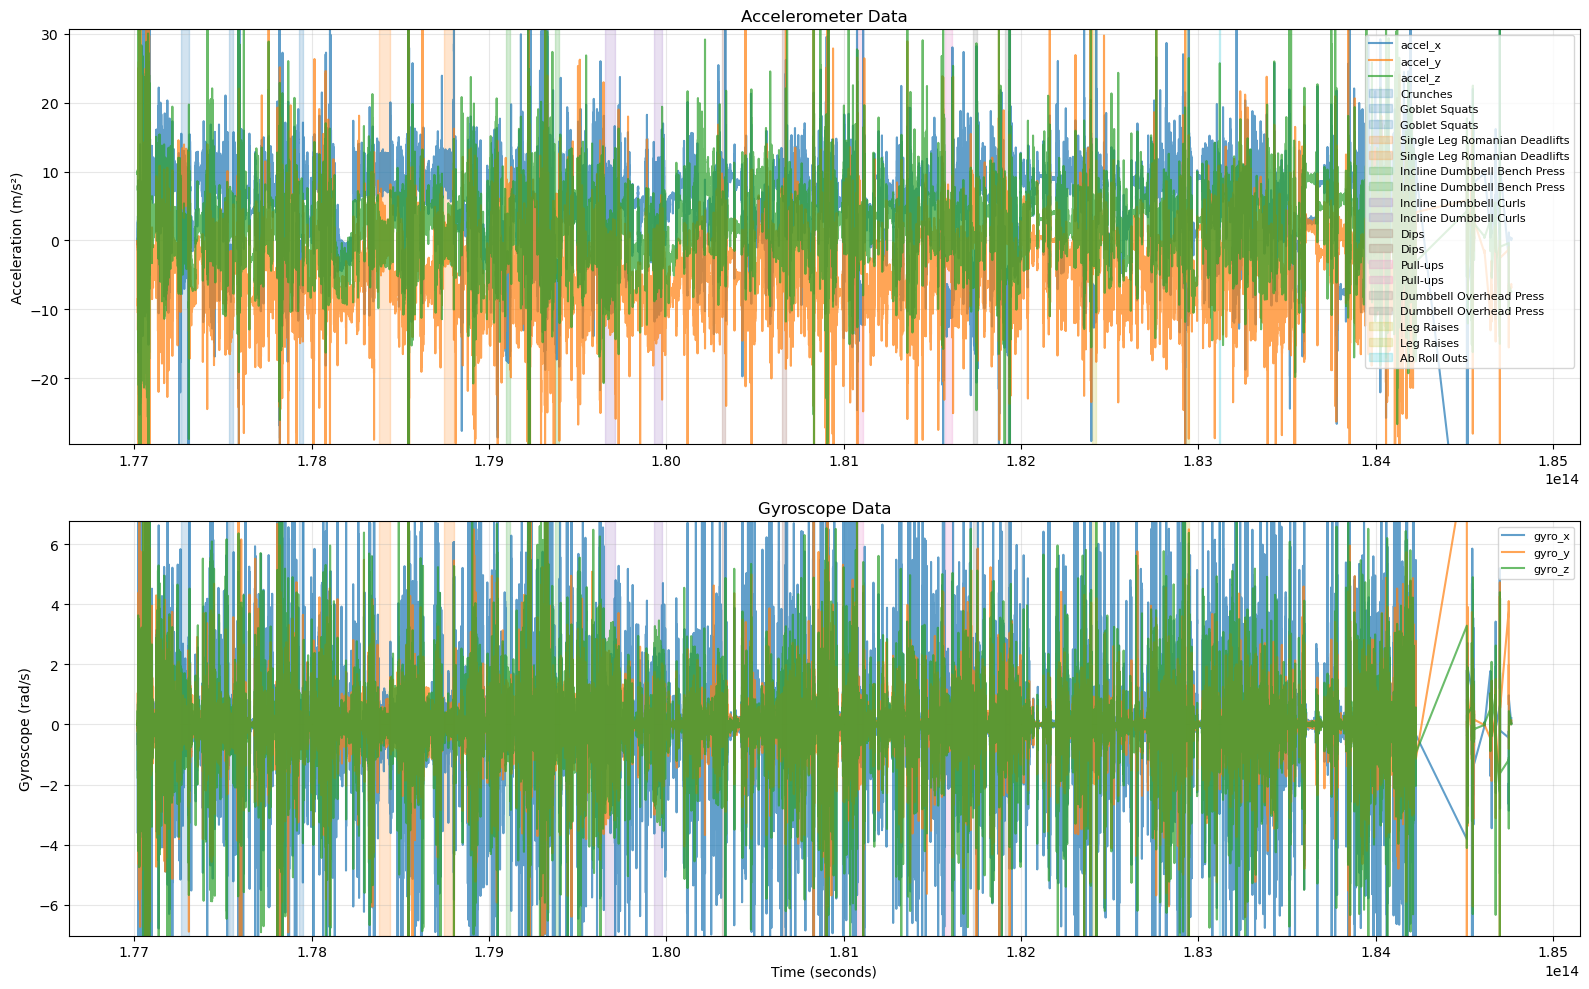

Event synthetic times (ms):
Crunches: 177262674198799ms - 177307245198799ms
Goblet Squats: 177534173198799ms - 177558447198799ms
Goblet Squats: 177928470198799ms - 177952349198799ms
Single Leg Romanian Deadlifts: 178381551198799ms - 178441493198799ms
Single Leg Romanian Deadlifts: 178743848198799ms - 178800452198799ms
Incline Dumbbell Bench Press: 179093670198799ms - 179120683198799ms
Incline Dumbbell Bench Press: 179372571198799ms - 179397063198799ms
Incline Dumbbell Curls: 179654374198799ms - 179709301198799ms
Incline Dumbbell Curls: 179931851198799ms - 179973889198799ms
Dips: 180312153198799ms - 180329308198799ms
Dips: 180650839198799ms - 180674009198799ms
Pull-ups: 181077193198799ms - 181110502198799ms
Pull-ups: 181573836198799ms - 181610512198799ms
Dumbbell Overhead Press: 181729663198799ms - 181750252198799ms
Dumbbell Overhead Press: 181912793198799ms - 181936970198799ms
Leg Raises: 182400689198799ms - 182425927198799ms
Leg Raises: 182928968198799ms - 182947374198799ms
Ab Roll Ou

In [34]:
plot_recording(combined_with_annotations, events_synthetic)

In [35]:
combined_with_annotations.iloc[38101]

timestamp    177782875249955
accel_x             6.828263
accel_y            -6.983886
accel_z             2.403779
gyro_x             -0.075747
gyro_y             -0.122173
gyro_z              0.025656
event                   None
Name: 38101, dtype: object

## Add predictions column to combined dataframe

In [36]:
# combined_with_annotations["timestamp"] matches in classification["accel_timestamps"]
def check_combined_classification_alignment(combined, classification):
    combined_timestamps = set(combined['timestamp'])
    for idx, row in classification.iterrows():
        accel_timestamps = set(int(ts) for ts in row['accel_timestamps'].split(';'))
        accel_in_combined = accel_timestamps.issubset(combined_timestamps)
        if not accel_in_combined:
            print(f"Row {idx}: Some accel timestamps not in combined")
    print("Alignment check completed.")

In [37]:
check_combined_classification_alignment(combined_with_annotations, classification)

Row 0: Some accel timestamps not in combined
Row 1: Some accel timestamps not in combined
Alignment check completed.


In [38]:
combined_with_predictions = add_predictions_to_combined(combined_with_annotations, classification)
combined_with_predictions.head(10)

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,event,prediction_float,prediction_binary
0,177017287198799,0.181959,-0.129287,9.722853,-0.046426,-0.006109,0.003665,None,0.029558,0.0
1,177017307230068,0.186748,-0.131681,9.761160,-0.029322,-0.004887,-0.002443,None,0.029558,0.0
2,177017327272222,0.189142,-0.093374,9.816227,-0.040317,-0.006109,-0.004887,None,0.037717,0.0
3,177017347310414,0.172383,-0.148441,9.825804,-0.031765,-0.002443,-0.008552,None,0.037717,0.0
4,177017367352029,0.208296,-0.045490,9.725247,-0.001222,-0.004887,-0.013439,None,0.037717,0.0
5,177017387379644,0.258574,-0.167594,9.825804,-0.014661,-0.006109,-0.008552,None,0.037717,0.0
6,177017409423337,0.155623,-0.225055,9.897630,-0.004887,-0.001222,-0.014661,None,0.037717,0.0
7,177017427443683,0.184354,-0.107739,9.892841,-0.001222,0.009774,-0.014661,None,0.037717,0.0
8,177017447473644,0.172383,-0.043096,9.773131,0.004887,0.013439,-0.008552,None,0.037717,0.0
9,177017467500029,0.191536,-0.186748,9.842564,0.050091,0.006109,-0.012217,None,0.037717,0.0


In [39]:
def plot_recording_with_predictions(data):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    time = data["timestamp"]

    # --- Plot 1: Accelerometer data ---
    ax1.plot(time, data['accel_x'], label='accel_x', alpha=0.7)
    ax1.plot(time, data['accel_y'], label='accel_y', alpha=0.7)
    ax1.plot(time, data['accel_z'], label='accel_z', alpha=0.7)

    accel_data = data[['accel_x', 'accel_y', 'accel_z']].values
    accel_min, accel_max = np.percentile(accel_data, [1, 99])
    accel_range = accel_max - accel_min
    ax1.set_ylim([accel_min - 0.5*accel_range, accel_max + 0.5*accel_range])
    ax1.set_ylabel('Acceleration (m/s²)')
    ax1.set_title('Accelerometer Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Gyroscope data ---
    ax2.plot(time, data['gyro_x'], label='gyro_x', alpha=0.7)
    ax2.plot(time, data['gyro_y'], label='gyro_y', alpha=0.7)
    ax2.plot(time, data['gyro_z'], label='gyro_z', alpha=0.7)

    gyro_data = data[['gyro_x', 'gyro_y', 'gyro_z']].values
    gyro_min, gyro_max = np.percentile(gyro_data, [1, 99])
    gyro_range = gyro_max - gyro_min
    ax2.set_ylim([gyro_min - 0.5*gyro_range, gyro_max + 0.5*gyro_range])
    ax2.set_ylabel('Gyroscope (rad/s)')
    ax2.set_title('Gyroscope Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    # --- Plot 3: Predictions ---
    ax3.plot(time, data['prediction_float'], label='Predictions', color='black', linewidth=1.5, alpha=0.7)
    ax3.plot(time, data['prediction_binary'], label='Exercise/ noexercise', color='red', linewidth=1.5, alpha=0.4)
    ax3.axhline(y=0.5, color='red', linestyle='--', label='threshold (0.5)')
    ax3.set_ylabel('Probability')
    ax3.set_xlabel('Time (ms)')
    ax3.set_ylim([-0.1, 1.1])
    ax3.grid(True, alpha=0.3)

    # --- Overlay Event Durations ---
    # 1. Identify where events start/end
    event_col = data['event'].fillna('None')
    event_changes = event_col != event_col.shift()
    data['event_group'] = event_changes.cumsum()

    # 2. Map unique events to colors (FIXED DEPRECATION)
    unique_events = [e for e in event_col.unique() if e != 'None']
    
    # Use the new recommended way to get the colormap
    cmap = plt.get_cmap('tab10') 
    event_to_color = {name: cmap(i % 10) for i, name in enumerate(unique_events)}

    # 3. Iterate through each contiguous block
    for _, group in data.groupby('event_group'):
        evt_name = group['event'].iloc[0]
        
        if pd.isna(evt_name) or evt_name == 'None':
            continue
            
        t_start = group['timestamp'].iloc[0]
        t_end = group['timestamp'].iloc[-1]
        color = event_to_color[evt_name]

        for ax in [ax1, ax2, ax3]:
            ax.axvspan(t_start, t_end, color=color, alpha=0.15)
            
            if ax == ax1:
                ax1.text((t_start + t_end) / 2, ax1.get_ylim()[1], evt_name, 
                        ha='center', va='bottom', color=color, fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()

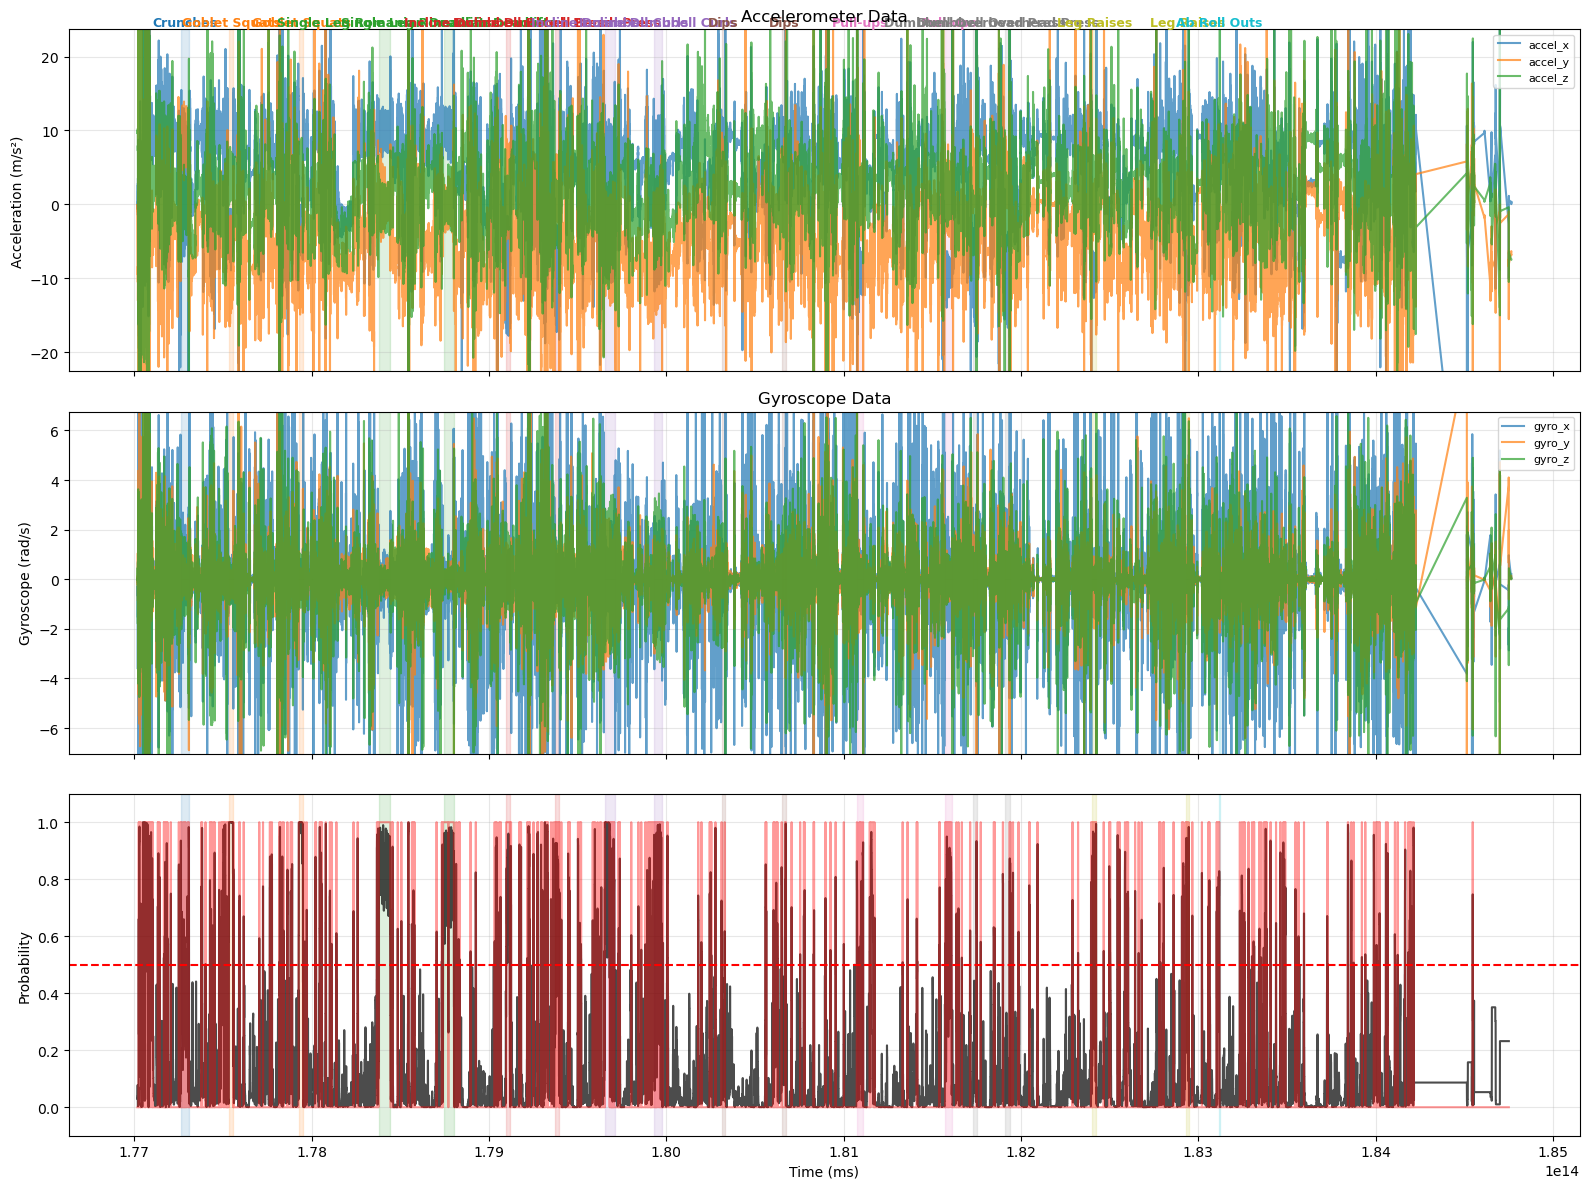

In [40]:
plot_recording_with_predictions(combined_with_predictions)

# smooth out predictions binary

In [41]:
df = combined_with_predictions

In [42]:
df.rolling

<bound method NDFrame.rolling of               timestamp   accel_x   accel_y   accel_z    gyro_x    gyro_y  \
0       177017287198799  0.181959 -0.129287  9.722853 -0.046426 -0.006109   
1       177017307230068  0.186748 -0.131681  9.761160 -0.029322 -0.004887   
2       177017327272222  0.189142 -0.093374  9.816227 -0.040317 -0.006109   
3       177017347310414  0.172383 -0.148441  9.825804 -0.031765 -0.002443   
4       177017367352029  0.208296 -0.045490  9.725247 -0.001222 -0.004887   
...                 ...       ...       ...       ...       ...       ...   
360540  184765034816440  0.304064 -6.325481 -7.503428  0.037874  0.147829   
360541  184765054879324  0.354342 -6.809110 -7.496245  0.019548  0.130725   
360542  184765074993940  0.035913 -6.866570 -7.486669  0.036652  0.118508   
360543  184765095078286  0.158017 -6.880936 -7.510611  0.151495  0.048869   
360544  184765115201132  0.296881 -6.833052 -7.467515  0.212581  0.042761   

          gyro_z event  prediction_float  

In [43]:
df = combined_with_predictions
for idx, row in df.iterrows():
    if idx < 3:
        continue

    previous3 = df.iloc[idx-3:idx-1]["prediction_binary"]

    print(previous3.values)

    if idx > 4:
        break

[0. 0.]
[0. 0.]
[0. 0.]
